### ***Image Caption Generator***

### *1*. Import the required Libraries

In [ ]:
# linear algebra
import numpy as np  
# data processing, CSV file I / O (e.g. pd.read_csv)
import pandas as pd  
import os
import string 
import tensorflow as tf
from keras.preprocessing.sequence import pad_sequences
from keras.preprocessing.text import Tokenizer
from keras.models import Model
from keras.layers import Flatten, Dense, LSTM, Dropout, Embedding, Activation
from keras.layers import concatenate, BatchNormalization, Input
from keras.layers.merge import add
from keras.utils import to_categorical, plot_model
from keras.applications.inception_v3 import InceptionV3, preprocess_input
import matplotlib.pyplot as plt  # for plotting data
import cv2

 - Mounting the Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### *2. Load the Descriptions*

In [ ]:
def load_description(text):
    mapping = dict()
    for line in text.split("\n"):
        token = line.split(",")
        if len(line) < 2:   # remove short descriptions
            continue
        img_id = token[0].split('.')[0] # name of the image
        img_des = token[1:]              # description of the image
        if img_id not in mapping:
            mapping[img_id] = list()
        mapping[img_id].append(img_des)
    return mapping
  
token_path = '/content/drive/My Drive/Colab Notebooks/DL-project/dataset/captions.txt'
text = open(token_path, 'r', encoding = 'utf-8').read()
descriptions = load_description(text)


In [ ]:
list(descriptions.keys())[:5]


['image',
 '1000268201_693b08cb0e',
 '1001773457_577c3a7d70',
 '1002674143_1b742ab4b8',
 '1003163366_44323f5815']

In [ ]:
descriptions['1000268201_693b08cb0e']

[['A child in a pink dress is climbing up a set of stairs in an entry way .'],
 ['A girl going into a wooden building .'],
 ['A little girl climbing into a wooden playhouse .'],
 ['A little girl climbing the stairs to her playhouse .'],
 ['A little girl in a pink dress going into a wooden cabin .']]

In [ ]:
print('Loaded: %d ' % len(descriptions))

Loaded: 8092 


### *3. Cleaning the Text*

In [ ]:
def clean_description(desc):
    for key, des_list in desc.items():
        for i in range(len(des_list)):
            caption = des_list[i]
            caption = [ch for ch in caption if ch not in string.punctuation]
            caption = ''.join(caption)
            caption = caption.split(' ')
            caption = [word.lower() for word in caption if len(word)>1 and word.isalpha()]
            caption = ' '.join(caption)
            des_list[i] = caption
  
clean_description(descriptions)
descriptions['1000268201_693b08cb0e']

['child in pink dress is climbing up set of stairs in an entry way',
 'girl going into wooden building',
 'little girl climbing into wooden playhouse',
 'little girl climbing the stairs to her playhouse',
 'little girl in pink dress going into wooden cabin']

In [ ]:
len(descriptions)

8092

In [ ]:
descriptions.keys()

dict_keys(['image', '1000268201_693b08cb0e', '1001773457_577c3a7d70', '1002674143_1b742ab4b8', '1003163366_44323f5815', '1007129816_e794419615', '1007320043_627395c3d8', '1009434119_febe49276a', '1012212859_01547e3f17', '1015118661_980735411b', '1015584366_dfcec3c85a', '101654506_8eb26cfb60', '101669240_b2d3e7f17b', '1016887272_03199f49c4', '1019077836_6fc9b15408', '1019604187_d087bf9a5f', '1020651753_06077ec457', '1022454332_6af2c1449a', '1022454428_b6b660a67b', '1022975728_75515238d8', '102351840_323e3de834', '1024138940_f1fefbdce1', '102455176_5f8ead62d5', '1026685415_0431cbf574', '1028205764_7e8df9a2ea', '1030985833_b0902ea560', '103106960_e8a41d64f8', '103195344_5d2dc613a3', '103205630_682ca7285b', '1032122270_ea6f0beedb', '1032460886_4a598ed535', '1034276567_49bb87c51c', '104136873_5b5d41be75', '1042020065_fb3d3ba5ba', '1042590306_95dea0916c', '1045521051_108ebc19be', '1048710776_bb5b0a5c7c', '1052358063_eae6744153', '105342180_4d4a40b47f', '1053804096_ad278b25f1', '1055623002_81

### *4. Generate the Vocabulary* 

In [ ]:
def to_vocabulary(descriptions):
	# build a list of all description strings
	all_desc = set()
	for key in descriptions.keys():
		[all_desc.update(d.split()) for d in descriptions[key]]
	return all_desc

# summarize vocabulary
vocabulary = to_vocabulary(descriptions)
print('Original Vocabulary Size: %d' % len(vocabulary))

Original Vocabulary Size: 8350


In [ ]:
# save descriptions to file, one per line
def save_descriptions(descriptions, filename):
	lines = list()
	for key, desc_list in descriptions.items():
		for desc in desc_list:
			lines.append(key + ' ' + desc)
	data = '\n'.join(lines)
	file = open(filename, 'w')
	file.write(data)
	file.close()

save_descriptions(descriptions, '/content/drive/My Drive/Colab Notebooks/DL-project/dataset/descriptions.txt')

### *5. Load Images* 

In [ ]:
def load_doc(filename):
	# open the file as read only
	file = open(filename, 'r')
	# read all text
	text = file.read()
	# close the file
	file.close()
	return text

In [ ]:
# load a pre-defined list of photo identifiers
def load_set(filename):
	doc = load_doc(filename)
	dataset = list()
	# process line by line
	for line in doc.split('\n'):
		# skip empty lines
		if len(line) < 1:
			continue
		# get the image identifier
		identifier = line.split('.')[0]
		dataset.append(identifier)
	return set(dataset)

# load training dataset (6K)
filename = '/content/drive/My Drive/Colab Notebooks/DL-project/dataset/Flickr_8k.trainImages.txt'

train = load_set(filename)
print('Dataset: %d' % len(train))

Dataset: 6000


In [ ]:
import glob

# Below path contains all the images
images = '/content/drive/My Drive/Colab Notebooks/DL-project/dataset/Images/'
# Create a list of all image names in the directory
img = glob.glob(images + '*.jpg')

In [ ]:
# Below file contains the names of images to be used in train data
train_images_file = '/content/drive/My Drive/Colab Notebooks/DL-project/dataset/Flickr_8k.trainImages.txt'
# Read the train image names in a set
train_images = set(open(train_images_file, 'r').read().strip().split('\n'))

# Create a list of all the training images with their full path names
train_img = []

for i in img: # img is list of full path names of all images
    if i[len(images):] in train_images: # Check if the image belongs to training set
        train_img.append(i) # Add it to the list of train images

In [ ]:
# Below file conatains the names of images to be used in test data
test_images_file = '/content/drive/My Drive/Colab Notebooks/DL-project/dataset/Flickr_8k.testImages.txt'
# Read the validation image names in a set# Read the test image names in a set
test_images = set(open(test_images_file, 'r').read().strip().split('\n'))

# Create a list of all the test images with their full path names
test_img = []

for i in img: # img is list of full path names of all images
    if i[len(images):] in test_images: # Check if the image belongs to test set
        test_img.append(i) # Add it to the list of test images

### *6. Forming a dictionary of images & descriptions* 

In [ ]:
def load_clean_descriptions(filename, dataset):
	# load document
	doc = load_doc(filename)
	descriptions = dict()
	for line in doc.split('\n'):
		# split line by white space
		tokens = line.split()
		# split id from description
		image_id, image_desc = tokens[0], tokens[1:]
		# skip images not in the set
		if image_id in dataset:
			# create list
			if image_id not in descriptions:
				descriptions[image_id] = list()
			# wrap description in tokens
			desc = 'startseq ' + ' '.join(image_desc) + ' endseq'
			# store
			descriptions[image_id].append(desc)
	return descriptions

# descriptions
train_descriptions = load_clean_descriptions('/content/drive/My Drive/Colab Notebooks/DL-project/dataset/descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))

Descriptions: train=6000


In [ ]:
train_descriptions['1000268201_693b08cb0e']

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq']

### *7. Extract the Feature Vector from images*

In [ ]:
def preprocess(image_path):
    # Convert all the images to size 299x299 as expected by the inception v3 model
    img = image.load_img(image_path, target_size=(299, 299))
    # Convert PIL image to numpy array of 3-dimensions
    x = image.img_to_array(img)
    # Add one more dimension
    x = np.expand_dims(x, axis=0)
    # preprocess the images using preprocess_input() from inception module
    x = preprocess_input(x)
    return x

In [ ]:
# Load the inception v3 model
model = InceptionV3(weights='imagenet')

96116736/96112376 [==============================] - 0s 0us/step


In [ ]:
# Create a new model, by removing the last layer (output layer) from the inception v3
model_new = Model(model.input, model.layers[-2].output)

In [ ]:
# Function to encode a given image into a vector of size (2048, )
def encode(image):
    image = preprocess(image) # preprocess the image
    fea_vec = model_new.predict(image) # Get the encoding vector for the image
    fea_vec = np.reshape(fea_vec, fea_vec.shape[1]) # reshape from (1, 2048) to (2048, )
    return fea_vec

In [ ]:
import pickle
from pickle import dump, load

(not to run the next code)

In [ ]:
# Call the funtion to encode all the train images
# This will take a while on CPU - Execute this only once
from time import time
from keras.preprocessing import image

start = time()
encoding_train = {}
for img in train_img:
    encoding_train[img[len(images):]] = encode(img)
print("Time taken in seconds =", time()-start)

Time taken in seconds = 1725.0633435249329


In [ ]:
import pickle
from pickle import dump, load

# Save the bottleneck train features to disk
with open("/content/drive/My Drive/Colab Notebooks/DL-project/dataset/Pickle/encoded_train_images.pkl.txt", "wb") as encoded_pickle:
    pickle.dump(encoding_train, encoded_pickle)

In [ ]:
# Call the funtion to encode all the test images - Execute this only once
start = time()
encoding_test = {}
for img in test_img:
    encoding_test[img[len(images):]] = encode(img)
print("Time taken in seconds =", time()-start)

Time taken in seconds = 282.99889183044434


In [ ]:

# Save the bottleneck test features to disk
with open("/content/drive/My Drive/Colab Notebooks/DL-project/dataset/Pickle/encoded_test_images.pkl.txt", "wb") as encoded_pickle:
    pickle.dump(encoding_test, encoded_pickle)

( Run this part to load the weights)

In [ ]:
train_features = load(open("/content/drive/My Drive/Colab Notebooks/DL-project/dataset/Pickle/encoded_train_images.pkl.txt","rb"))
print('Photos: train=%d' % len(train_features))

Photos: train=6000


### *8. Tokenise the Vocabulary* 

In [ ]:
# Create a list of all the training captions
all_train_captions = []
for key, val in train_descriptions.items():
    for cap in val:
        all_train_captions.append(cap)
len(all_train_captions)

30000

In [ ]:
# Consider only words which occur at least 10 times in the corpus
word_count_threshold = 10
word_counts = {}
nsents = 0
for sent in all_train_captions:
    nsents += 1
    for w in sent.split(' '):
        word_counts[w] = word_counts.get(w, 0) + 1

vocab = [w for w in word_counts if word_counts[w] >= word_count_threshold]
print('preprocessed words %d -> %d' % (len(word_counts), len(vocab)))

preprocessed words 7259 -> 1638


In [ ]:
ixtoword = {}
wordtoix = {}

ix = 1
for w in vocab:
    wordtoix[w] = ix
    ixtoword[ix] = w
    ix += 1

In [ ]:
vocab_size = len(ixtoword) + 1 # one for appended 0's
vocab_size

1639

In [ ]:
# convert a dictionary of clean descriptions to a list of descriptions
def to_lines(descriptions):
	all_desc = list()
	for key in descriptions.keys():
		[all_desc.append(d) for d in descriptions[key]]
	return all_desc

# calculate the length of the description with the most words
def max_length(descriptions):
	lines = to_lines(descriptions)
	return max(len(d.split()) for d in lines)

# determine the maximum sequence length
max_length = max_length(train_descriptions)
print('Description Length: %d' % max_length)

Description Length: 32


### *9. GloVe vector embeddings* 

In [ ]:
X1, X2, y = list(), list(), list()
for key, des_list in train_descriptions.items():
    pic = train_features[key + '.jpg']
    for cap in des_list:
        seq = [wordtoix[word] for word in cap.split(' ') if word in wordtoix]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen = max_length)[0]
            out_seq = to_categorical([out_seq], num_classes = vocab_size)[0]
            # store
            X1.append(pic)
            X2.append(in_seq)
            y.append(out_seq)

In [ ]:
X2 = np.array(X2)
X1 = np.array(X1)
y = np.array(y)
  
# load glove vectors for embedding layer
embeddings_index = {}
golve_path ='/content/drive/My Drive/Colab Notebooks/DL-project/glove.6B.200d.txt'
glove = open(golve_path, 'r', encoding = 'utf-8').read()
for line in glove.split("\n"):
    values = line.split(" ")
    word = values[0]
    indices = np.asarray(values[1: ], dtype = 'float32')
    embeddings_index[word] = indices
  


In [ ]:
emb_dim = 200
emb_matrix = np.zeros((vocab_size, emb_dim))
for word, i in wordtoix.items():
    emb_vec = embeddings_index.get(word)
    if emb_vec is not None:
        emb_matrix[i] = emb_vec
emb_matrix.shape

(1639, 200)

### *10. The Model defination*

( don't run )

In [ ]:
# define the model

# image feature extractor model
ip1 = Input(shape = (2048, ))
fe1 = Dropout(0.2)(ip1)
fe2 = Dense(256, activation = 'relu')(fe1)

# partial caption sequence model
ip2 = Input(shape = (max_length, ))
se1 = Embedding(vocab_size, emb_dim, mask_zero = True)(ip2)
se2 = Dropout(0.2)(se1)
se3 = LSTM(256)(se2)

# decoder (feed forward) model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation = 'relu')(decoder1)
outputs = Dense(vocab_size, activation = 'softmax')(decoder2)

# merge the two input models
model = Model(inputs = [ip1, ip2], outputs = outputs)

In [ ]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 32)]         0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 2048)]       0                                            
__________________________________________________________________________________________________
embedding (Embedding)           (None, 32, 200)      327800      input_3[0][0]                    
__________________________________________________________________________________________________
dropout (Dropout)               (None, 2048)         0           input_2[0][0]                    
____________________________________________________________________________________________

### *11. Train the model*

In [ ]:
model.layers[2].set_weights([emb_matrix])
model.layers[2].trainable = False
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam')
model.fit([X1, X2], y, epochs = 15, batch_size = 250)


Epoch 1/15
1164/1164 [==============================] - 137s 114ms/step - loss: 2.9127
Epoch 2/15
1164/1164 [==============================] - 133s 114ms/step - loss: 2.7253
Epoch 3/15
1164/1164 [==============================] - 132s 114ms/step - loss: 2.6015
Epoch 4/15
1164/1164 [==============================] - 131s 113ms/step - loss: 2.5186
Epoch 5/15
1164/1164 [==============================] - 131s 113ms/step - loss: 2.4353
Epoch 6/15
1164/1164 [==============================] - 130s 112ms/step - loss: 2.3674
Epoch 7/15
1164/1164 [==============================] - 130s 111ms/step - loss: 2.3126
Epoch 8/15
1164/1164 [==============================] - 130s 111ms/step - loss: 2.2617
Epoch 9/15
1164/1164 [==============================] - 129s 110ms/step - loss: 2.2192
Epoch 10/15
1164/1164 [==============================] - 129s 111ms/step - loss: 2.1713
Epoch 11/15
1164/1164 [==============================] - 128s 110ms/step - loss: 2.1399
Epoch 12/15
1164/1164 [==================

In [ ]:
model.save('/content/drive/My Drive/Colab Notebooks/DL-project/dataset/model/dl_model')

INFO:tensorflow:Assets written to: /content/drive/My Drive/Colab Notebooks/DL-project/dataset/model/dl_model/assets


INFO:tensorflow:Assets written to: /content/drive/My Drive/Colab Notebooks/DL-project/dataset/model/dl_model/assets


### *12. Predict the Output*

(Run from here)

In [ ]:
from tensorflow import keras
model = keras.models.load_model('/content/drive/My Drive/Colab Notebooks/DL-project/dataset/model/dl_model')


In [ ]:
with open("/content/drive/My Drive/Colab Notebooks/DL-project/dataset/Pickle/encoded_test_images.pkl.txt", "rb") as encoded_pickle:
    encoding_test = load(encoded_pickle)

In [ ]:
def greedySearch(photo):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = [wordtoix[w] for w in in_text.split() if w in wordtoix]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo,sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = ixtoword[yhat]
        in_text += ' ' + word
        if word == 'endseq':
            break
    final = in_text.split()
    final = final[1:-1]
    final = ' '.join(final)
    return final

### *13. Output Predictions*

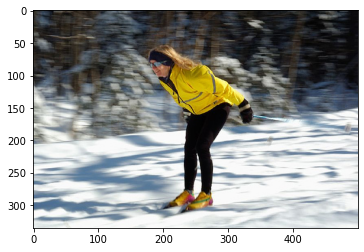

Greedy Predicted: man in red jacket and helmet is jumping in the snow
Actual: woman in yellow and black outfit is skiing


BLEU Score : 0.3716224224737354


In [ ]:
z=0
z+=1
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy Predicted:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])

print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

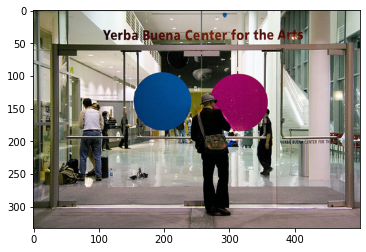

Greedy: man in red jacket is holding up sign that is holding
Actual: man is standing in front of glass doors with blue spot and pink spot


BLEU Score : 0.3798813800883541


In [ ]:
z = 12
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

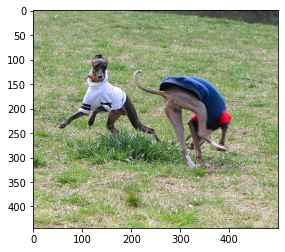

Greedy: two dogs are playing with toy
Actual: the two greyhound dogs wearing sweaters are playing in the grass


BLEU Score : 0.4712041065283682


In [ ]:
z = 17
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

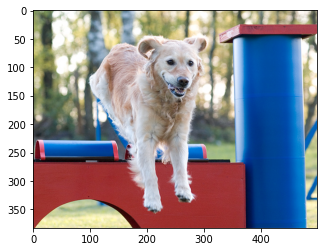

Greedy: dog is running through the grass
Actual: dog is jumping across an obstacle


BLEU Score : 0.3918149551368407


In [ ]:
z = 50
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

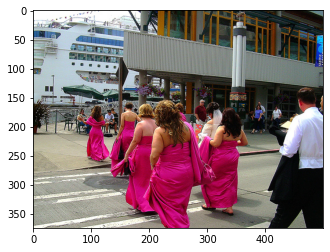

Greedy: group of people are standing on sidewalk outside of building
Actual: group of woman in pink dresses walking across crosswalk towards cruisship


BLEU Score : 0.35715384284362606


In [ ]:
z = 114
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

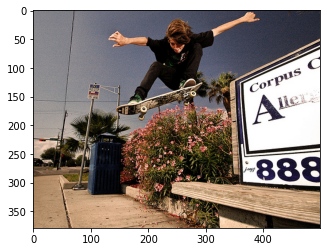

Greedy: skateboarder doing trick in midair
Actual: boy is outside jumping over flower bush on skateboard


BLEU Score : 0.4126730129661947


In [ ]:
z = 221
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

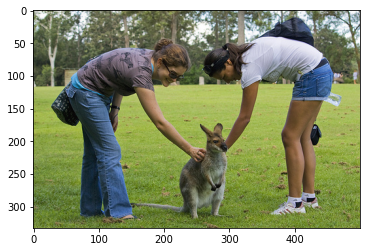

Greedy: man and dog are playing with toy
Actual: woman in jeans and woman in shorts are petting baby kangaroo


BLEU Score : 0.4380624371435032


In [ ]:
z = 251
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

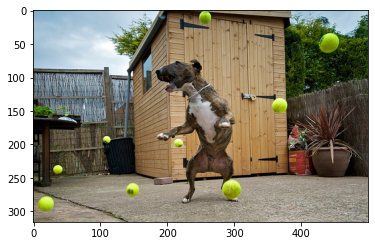

Greedy: dog catches tennis ball in its mouth
Actual: big dog stands on his hand leg as tennis balls are thrown his direction


BLEU Score : 0.4029349458313456


In [ ]:
z = 334
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

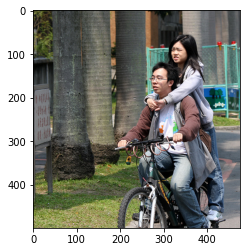

Greedy: man and woman ride bikes across the street
Actual: male and female on one seat bike ride along tree lined road


BLEU Score : 0.3638728701486349


In [ ]:
z = 328
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)

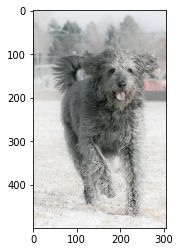

Greedy: black dog running on the sand
Actual: furry dog running on an open field of grass


BLEU Score : 0.4080747266211157


In [ ]:
z = 424
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic)
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
img_no = pic.split('.')[0]
print("Actual:", descriptions[img_no][0])
print('\n')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4
reference =  descriptions[img_no][0]
candidate =  greedySearch(image)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
print('BLEU Score :', score)